# Линейная алгебра, математический анализ

### 1. Линейная алгебра

1. Даны матрицы

$$
A =
\begin{pmatrix}
2 & -4 \\
3 & 5 \\
-1 & 0
\end{pmatrix}
,
\quad
B = 
\begin{pmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{pmatrix}
,
\quad
C = 
\begin{pmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{pmatrix}
$$

Посчитайте матрицу $D = A^{T}С - 2A^{T}B^{T}$. Приведите полную последовательность вычислений.

In [3]:
from sympy import Matrix, solve, latex, init_printing
from IPython.display import display, Math

init_printing()

A = Matrix([
    [2, -4],
    [3, 5],
    [-1, 0]])

B = Matrix([
    [1, 2, 7],
    [-3, -4, 0],
    [5, 2, 1]])

C = Matrix([
    [6, -3, 9],
    [4, -5, 2],
    [8, 1, 5]])

display(Math(f"""
    A = {latex(A, mat_delim="(")},
    B = {latex(B, mat_delim="(")},
    C = {latex(C, mat_delim="(")} \\\\[1em]
    A^T = {latex(A.T, mat_delim="(")}, 
    B^T = {latex(B.T, mat_delim="(")} \\\\[1em]
    A^T \\times C = {latex(A.T, mat_delim="(")} \\times {latex(C, mat_delim="(")} 
          = {latex(A.T * C, mat_delim="(")} \\\\[1em]
    2 A^T B^T = 2 \\cdot \\left( {latex(A.T, mat_delim="(")} \\times {latex(B.T, mat_delim="(")} \\right)
              = 2 \\cdot {latex(A.T * B.T, mat_delim="(")}
              = {latex(2 * A.T * B.T, mat_delim="(")} \\\\[1em]
    D = A^T C - 2 A^T B^T = {latex(A.T * C, mat_delim="(")} - {latex(2 * A.T * B.T, mat_delim="(")} 
      = {latex(A.T * C - 2 * A.T * B.T, mat_delim="(")}
    """))

<IPython.core.display.Math object>

2. Дано выражение

$$
3 \cdot
\begin{pmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{pmatrix}
+
2 \cdot
\begin{pmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{pmatrix}
=
\begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}
$$

Найдите значения $x$, $y$, $z$ и $v$, при которых выражение верно.

In [ ]:
from sympy import Matrix, symbols, solve, Eq, init_printing, latex
from IPython.display import display, Math

init_printing()

x, y, z, v = symbols("x y z v")

A = Matrix([
    [x, 2, 3],
    [-1, y, 4]
])

B = Matrix([
    [1, 2, -5],
    [2, -6, z]
])

C = Matrix([
    [8, v, -1],
    [1, 6, 4]
])

equation = 3 * A + 2 * B - C
rows, cols = equation.shape
equations = [Eq(equation[i, j], 0) for j in range(cols) for i in range(rows)]
equations = [e for e in equations if e != True]

solution_final = solve(equations, (x, y, z, v))

display(Math(f"""
    Исходное \\ выражение: \\\\[1em]
    3 \\cdot {latex(A, mat_delim="(")} + 2 \\cdot {latex(B, mat_delim="(")}
    = {latex(C, mat_delim="(")} \\\\[1em]
    {latex(3 * A, mat_delim="(")} + {latex(2 * B, mat_delim="(")} - {latex(C, mat_delim="(")} = 0 \\\\[1em]
    {latex(3 * A + 2 * B - C, mat_delim="(")} = 0 \\\\[1em]
    Выделим \\ и \\ решим \\ систему \\ линейных \\ уравнений: \\\\[1em]
    \\begin{{cases}}
    {'; \\\\'.join([latex(e) for e in equations])}
    \\end{{cases}} \\\\[1em]
    Т.к. \\ все \\ уравнения \\ однозначны, \\ легко \\ найти \\ все \\ неизвестные: \\\\[1em]
    \\begin{{cases}}
    {'; \\\\'.join([f"{latex(var)} = {latex(val)}" for var, val in solution_final.items()])}
    \\end{{cases}} \\\\[1em]
"""))

<IPython.core.display.Math object>

3. Укажите те значения параметров p и q, при которых ранг матрицы 
$A = \begin{pmatrix} 
1 & 2 & 3 \\
3 & 6 & p \\
5 & 10 & q
\end{pmatrix}$
равен единице.

In [234]:
from sympy import Matrix, symbols, latex, solve, Eq, init_printing
from IPython.display import display, Math

init_printing()

p, q = symbols("p q")

A = Matrix([
    [1, 2, 3],
    [3, 6, p],
    [5, 10, q]
])

equations = [
    Eq(A[[0, 1], [1, 2]].det(), 0),
    Eq(A[[0, 2], [1, 2]].det(), 0)
]

solution_final = solve(equations, (p, q))

display(Math(f"""
    A(p, q) = {latex(A, mat_delim="(")} \\\\[1em]
    Для \\ того, \\ чтобы \\ ранг \\ был \\ равен \\ 1, \\ 
    нужно \\ чтобы \\ все \\ миноры \\ 2-го \\ порядка \\ были \\ равны \\ 0 \\\\[1em]
    Для \\ начала \\ выделим \\ все \\ миноры \\ в \\ части \\ матрицы \\ с \\ известными \\ 
    {latex(A[:, :2], mat_delim="(")}, а \\ именно: \\\\[1em]
    detM_1 = \\left{"|"}{latex(A[[0, 1], [0, 1]], mat_delim="")}\\right{"|"} = {latex(A[[0, 1], [0, 1]].det())}, \\
    detM_2 = \\left{"|"}{latex(A[[0, 2], [0, 1]], mat_delim="")}\\right{"|"} = {latex(A[[0, 2], [0, 1]].det())}, \\
    detM_3 = \\left{"|"}{latex(A[[1, 2], [0, 1]], mat_delim="")}\\right{"|"} = {latex(A[[0, 2], [0, 1]].det())} \\\\[1em]
    Как \\ видно, \\ миноры \\ равны \\ нулю, \\ соответственно, \\ остальные \\ миноры \\ части \\ матрицы \\ 
    {latex(A[:, 1:3], mat_delim="(")} так \\ же \\ должны \\ равнятся \\ нулю. \\\\[1em]
    По \\ аналогии \\ выделим \\ все \\ миноры: \\\\[1em]
    detM_4 = \\left{"|"}{latex(A[[0, 1], [1, 2]], mat_delim="")}\\right{"|"} = {latex(A[[0, 1], [1, 2]].det())} = 0, \\
    detM_5 = \\left{"|"}{latex(A[[0, 2], [1, 2]], mat_delim="")}\\right{"|"} = {latex(A[[0, 2], [1, 2]].det())} = 0, \\
    detM_6 = \\left{"|"}{latex(A[[1, 2], [1, 2]], mat_delim="")}\\right{"|"} = {latex(A[[1, 2], [1, 2]].det())} = 0 \\\\[1em]    
    миноры \\ M_4, \\ M_5 \\ и \\ M_6 \\ можно \\ выделить \\ в \\ СЛУ: \\\\[1em]
    \\begin{{cases}}
    {latex(A[[0, 1], [1, 2]].det())} = 0; \\\\
    {latex(A[[0, 2], [1, 2]].det())} = 0; \\\\
    {latex(A[[1, 2], [1, 2]].det())} = 0
    \\end{{cases}} \\\\[1em]
    Решение \\ данной \\ СЛУ \\ однозначно \\ и \\ легко \\ увидеть, \\ что \\
    \\operatorname{{rank}} \\bigl( A(p, q) \\bigr) = 1 \\iff 
    \\begin{{cases}}
    {'; \\\\'.join([f"{latex(var)} = {latex(val)}" for var, val in solution_final.items()])}
    \\end{{cases}} \\\\[1em]    
"""))

<IPython.core.display.Math object>

4. Относительно канонического (стандартного) базиса в $\mathbb{R}^2$ даны три вектора $a_1 = (2, −5)^⊤$, $a_2 = (−1, 3)^⊤$
и $x = (1, −4)^⊤$. Примите векторы $a_1, a_2$ за новый базис $B$, предварительно проверив, что они линейно
независимы.\
(a) Найдите координаты вектора $[x]_B$ вектора $x$ в новом базисе.\
(b) Предположим, что координаты вектора $y$ в базисе $B$ заданы $[y]_B = (1, 1)^T$. 
Найдите координаты вектора $y$ в стандартном базисе.

In [236]:
from sympy import Matrix, symbols, Eq, solve
from IPython.display import Math, display

alpha, beta = symbols("alpha beta")

e1 = Matrix([1, 0])
e2 = Matrix([0, 1])
a1 = Matrix([2, -5])
a2 = Matrix([-1, 3])
B = a1.row_join(a2).T
x = Matrix([1, -4])
xb = Matrix([alpha, beta])
y = Matrix([1, 1])

eq_a = Eq(xb[0] * a1 + xb[1] * a2, x)
solution_a = solve(eq_a, (alpha, beta))
eq_b = y[0] * a1 + y[1] * a2


display(Math(f"""
    Канонический \\ базис \\ здесь \\ 
    e_1 =\\begin{{pmatrix}} 1 \\\\ 0 \\end{{pmatrix}} \\ и \\
    e_2 =\\begin{{pmatrix}} 0 \\\\ 1 \\end{{pmatrix}} \\Rightarrow
    Для \\ нахождения \\ вектора \\ {latex(x, mat_delim="(")} \\ 
    в \\ каноническом \\ базисе \\ используется \\ формула: \\\\[1em]
    [x] = x_1 \\cdot e_1 + x_2 \\cdot e_2 = 
    {latex(x[0])} \\cdot {latex(e1, mat_delim="(")} + ({latex(x[1])}) \\cdot {latex(e2, mat_delim="(")} = 
    {latex(x[0] * e1 + x[1] * e2, mat_delim="(")} \\\\[1em]
    Чтобы \\ найти \\ этот \\ же \\ вектор \\ в \\ новом \\ базисе \\ 
    B = {latex(B, mat_delim="(")}, \\ покажем, \\ что \\ определитель \\ не \\ равен \\ нулю: \\
    detB = {latex(B.det())} \\\\[1em]
    Перепишем \\ формулу \\ для \\ определения \\ вектора {latex(x, mat_delim="(")} в \\ новом \\ базисе: \\\\[1em]
    [x]_B = \\alpha \\cdot a_1 + \\beta \\cdot a_2 
          = \\alpha \\cdot {latex(a1, mat_delim="(")} + \\beta \\cdot {latex(a2, mat_delim="(")} \\\\[1em]
    Итоговое \\ уравнение \\ будет \\ иметь \\ вид: \\\\[1em]
    \\alpha \\cdot {latex(a1, mat_delim="(")} + \\beta \\cdot {latex(a2, mat_delim="(")} 
    = {latex(x, mat_delim="(")} \\\\[1em]
    Преобразуем \\ в \\ СЛУ: \\\\[1em]
    (a) \\begin{{cases}}
    {"; \\\\".join([f"{latex(eq)} &= &{latex(eq_a.rhs[i])}" for i, eq in enumerate(eq_a.lhs)])}
    \\end{{cases}} \\Rightarrow
    [x]_B = \\begin{{pmatrix}} {latex(solution_a[alpha])} \\\\ {latex(solution_a[beta])} \\end{{pmatrix}} \\\\[1em]
    (b) \\ [y] = y_1 \\cdot a_1 + y_2 \\cdot a_2 
    = {latex(y[0])} \\cdot {latex(a1, mat_delim="(")} + {latex(y[1])} \\cdot {latex(a2, mat_delim="(")}
    = {latex(eq_b, mat_delim="(")}
"""))


<IPython.core.display.Math object>

5. Исследовательское задание: малоранговая аппроксимация матрицы. Сгенерируйте случайную квадратную матрицу $A ∈ \mathbb{R}^{n×n}, n ≥ 100$. С помощью функции $numpy.linalg.svd$ выполните сингулярное разложение этой матрицы, и получите три матрицы: $U, S, V^⊤$. Выполняйте аппроксимацию матрицы $\bar{A}$ с
рангом $r$, меняя его значение, например, от $2$ до $n$:

    $\bar{A} = U[:, :r] S[:r, :r] V^T[:r, :]$,

    и каждый раз считайте ошибку апроксимации (как восстановленная матрица отличается от исходной):

    $E(r) = \|A - \bar{A}\|_F = \sqrt{\sum\limits_{i=1}^{n} \sum\limits_{j=1}^{n} (a_{ij} - \bar{a}_{ij})^2}$

    Используя библиотеку $matplotlib$, постройте график зависимости ошибки аппроксимации матрицы от ранга $r$.

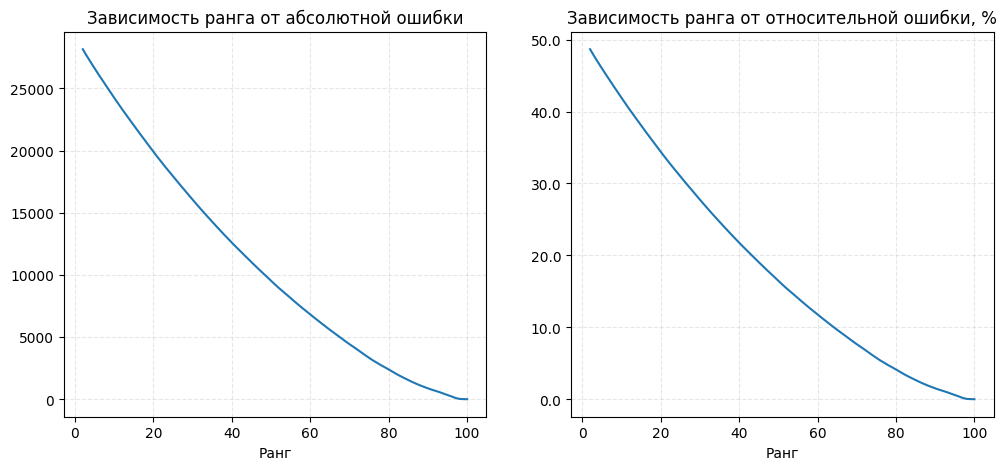

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def approximation(A, r):
    U, sigma, Vt = np.linalg.svd(A, full_matrices=True)
    S = np.diag(sigma)
    U = U[:, :r]
    S = S[:r, :r]
    Vt = Vt[:r, :]
    
    A_ = U @ S @ Vt
    return A_

n = 100
A = np.random.randint(0, 1000, (n, n))

error = {"abs": [], "rel": [], "rank": []}
for rank in range(2, n + 1):
    A_ = approximation(A, rank)
    absolute = np.linalg.norm(A - A_)
    error["abs"].append(absolute)

    relative = absolute / np.linalg.norm(A)
    error["rel"].append(relative)

    error["rank"].append(rank)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(error["rank"], error["abs"])
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.set_title("Зависимость ранга от абсолютной ошибки")
ax1.set_xlabel("Ранг")

ax2.plot(error["rank"], error["rel"])
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.set_title("Зависимость ранга от относительной ошибки, %")
ax2.set_xlabel("Ранг")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*100:.01f}"))
plt.show()

### 2. Начала мат.анализа и оптимизации.

1. Посчитайте градиент следующей функции:

$f(x) = x_1^{3} + 2x_1x_2 + x_2^{2} - 3x_1 - 2x_2, x \in \mathbb{R}^2$

Найдите критические точки $x_c$ такие, что $\nabla f(x_c) = 0$

<IPython.core.display.Math object>

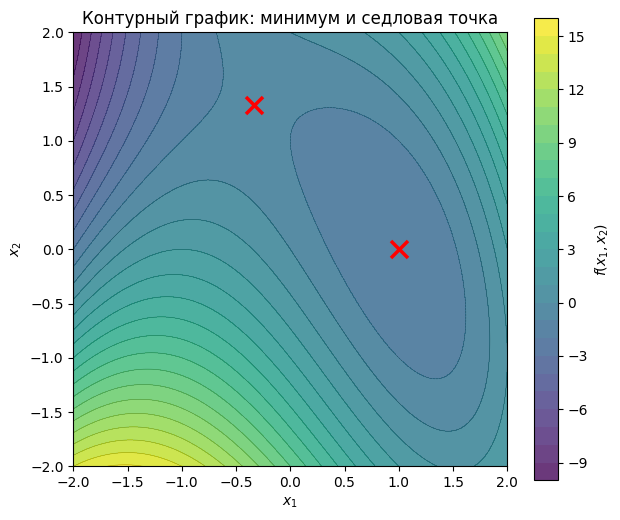

In [237]:
import numpy as np
from sympy import Eq, solve, diff, symbols, Matrix, latex, simplify, sqrt
from IPython.display import display, Math

x1, x2 = symbols('x1 x2')
a, b, c = symbols('a b c')

def f(x1, x2):
    return x1**3 + 2 * x1 * x2 + x2**2 - 3 * x1 - 2 * x2

grad = Matrix([diff(f(x1, x2), var) for var in (x1, x2)])
eq1 = Eq(grad[0], 0)
eq2 = Eq(grad[1], 0)
x2_expr = solve(simplify(eq2), (x2))[0]
eq1_subs = eq1.subs(x2, x2_expr)
polynom_x1 = eq1_subs.as_poly() 

equations = [
    eq1_subs,
    Eq(x2, x2_expr)
]
solution_x1 = solve(eq1_subs, (x1))
solution_final = solve(equations, (x1, x2))

display(Math(f"""
    Найдем \\ градиент \\ для \\ x_1 \\ и \\ x_2 \\ по \\ правилам \\ частной \\ производной: \\\\[1em]
    \\nabla f(x) = \\begin{{pmatrix}} 
        \\frac{{\\partial f}}{{\\partial x_1}} \\\\[0.5em]
        \\frac{{\\partial f}}{{\\partial x_2}}
    \\end{{pmatrix}} = {latex(grad, mat_delim="(")} \\\\[1em]
    Для \\ нахождения \\ критических \\ точек \\ решим \\ СУ: \\\\[1em]
    \\begin{{cases}}
    {"; \\\\".join(f"{latex(eq)} = 0" for eq in grad)}
    \\end{{cases}} \\\\[1em]
    Выразим \\ СУ \\ через \\ x_2: \\\\[1em]
    \\begin{{cases}}
    {"; \\\\".join(latex(eq) for eq in equations)}  
    \\end{{cases}} \\\\[1em]
    Решим \\ первое \\ уравнение \\ через \\ дискиминант, \\ найдя \\ все \\ его \\ корни: \\\\[1em]
    D = b^2 - 4ac, \\ x_1 = \\frac{{-b \\pm \\sqrt{{D}}}}{{2a}} \\Rightarrow 
    x_1^{{(1)}} = {latex(solution_x1[0])}, \\ x_1^{{(2)}} = {latex(solution_x1[1])} \\\\[1em]
    Подставив \\ соответствующие \\ корни \\ x_1 \\ во \\ второе \\ уравнение \\ получим \\ критические \\ точки: \\\\[1em]
    {", ".join(f"x_c^{{({i+1})}} = {latex(root)}" for i, root in enumerate(solution_final))}, \\
    из \\ графика \\ видно \\ что \\ x_c^{{(1)}} - седловая \\ точка, \\ а \\ x_c^{{(2)}} - точка \\ локального \\ минимума
"""))

import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)
F_X = f(X1, X2)

plt.figure(figsize=(7, 6))
cont = plt.contourf(X1, X2, F_X, levels=30, cmap='viridis', alpha=0.8)
plt.contour(X1, X2, F_X, levels=30, colors='black', linewidths=0.4, alpha=0.3)
plt.colorbar(cont, label='$f(x_1, x_2)$')

plt.scatter([solution_final[0][0], solution_final[1][0]], 
            [solution_final[0][1], solution_final[1][1]], 
            color='red', marker='x', s=150, linewidths=2.5)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title('Контурный график: минимум и седловая точка')
plt.gca().set_aspect('equal')
plt.show()




2. Проверьте, что функция $f = \ln(\sqrt{x_1} + \sqrt{x_2})$ удовлетворяет уравнению:
$$
x_1 \frac{\partial f}{\partial x_1} + x_2 \frac{\partial f}{\partial x_2} = \frac{1}{2}
$$

In [291]:
from sympy import ln, sqrt, diff, symbols, solve, simplify
from IPython.display import Math, display

x1, x2, u = symbols('x1 x2 u')

f = ln(u)
df_du = diff(f, u)
eq1 = sqrt(x1) + sqrt(x2)
df_du2x = df_du.subs(u, eq1)
du_dx1 = diff(eq1, x1)
du_dx2 = diff(eq1, x2)

df_dx1 = df_du2x * du_dx1
df_dx2 = df_du2x * du_dx2

eq_left = x1 * df_dx1
eq_right = x2 * df_dx2
result = simplify(eq_left + eq_right)

display(Math(f"""
    Для \\ начала \\ сделаем \\ замену \\ переменной: \\\\[1em]
    u = {latex(eq1)} \\ \\Rightarrow \\
    f(u(x_1, x_2)) = \\ln(u) \\\\[1em]
    Далее \\ по \\ цепному \\ правилу \\ вычислим \\ частные \\ производные: \\\\[1em]
    \\frac{{\\partial f}}{{\\partial x_1}} = \\frac{{\\partial f}}{{\\partial u}} \\cdot \\frac{{\\partial u}}{{\\partial x_1}} = 
    \\ln'(u) \\cdot u' = {latex(df_du)} \\cdot u' = {latex(df_du2x)} \\cdot {latex(du_dx1)} \\\\[1em]
    Аналогично \\ найдем \\ и \\ для \\ x_2: \\\\[1em]
    \\frac{{\\partial f}}{{\\partial x_2}} = {latex(df_du2x)} \\cdot {latex(du_dx2)} \\\\[1em]
    Теперь \\ проверим \\ что \\ верно \\ уравнение: \\\\[1em]
    x_1 \\frac{{\\partial f}}{{\\partial x_1}} + x_2 \\frac{{\\partial f}}{{\\partial x_2}} = \\frac{{1}}{{2}} \\\\[1em]
    Возьмем \\ левую \\ часть \\ уравнения \\ и \\ подставим \\ значения \\ частных \\ производных: \\\\[1em]
    {latex(x1)} \\cdot {latex(df_dx1)} + {latex(x2)} \\cdot {latex(df_dx2)} = 
    {latex(eq_left)} + {latex(eq_right)} = \\frac{{1}}{{2}} \\cdot \\frac{{\\cancel{{{latex(eq1)}}}}}{{\\cancel{{{latex(eq1)}}}}} = 
    {latex(result)} \\Rightarrow \\frac{{1}}{{2}} = {latex(result)} 
"""))

<IPython.core.display.Math object>

3. Предположим, задана $f : \mathbb{R^3} \rightarrow \mathbb{R^2}$:
$$
f(x, y, z) = (x + y + z, \ xyz)^T
$$
Найдите матрицу Якоби $J_f$ функции $f$, и ее численное значение в точке $v = (1, 2, 3)^T$

In [343]:
from sympy import symbols, Matrix
from IPython.display import display, Math

x, y, z = symbols('x y z')
v = [1, 2, 3]

f = Matrix([x + y + z, x * y * z])
J = f.jacobian([x, y, z])
result = J.subs({key: value for key, value in zip((x, y, z), v)})

J_disp = ""
for i in range(len(f)):
    for var in (x, y, z):
        J_disp += f"\\frac{{\\partial f_{i+1}}}{{\\partial {var}}} "
    J_disp += " \\\\[0.5em]"
J_disp = "\\begin{pmatrix} " + J_disp + " \\end{pmatrix}"  

display(Math(f""" 
    Чтобы \\ вычислить \\ матрицу \\ Якоби, \\ требуется \\ найти \\ все \\ частные \\ производные \\ вектора \\ f: \\\\[1em]
    J_f = {J_disp} = {latex(J, mat_delim="(")} \\\\[1em]
    Подставив \\ v = {latex(Matrix(v).T, mat_delim="(")}^T \\ получим \\ численное \\ решение: \\\\[1em]
    J_f = {latex(J, mat_delim="(")} = {latex(result, mat_delim="(")}
"""))

<IPython.core.display.Math object>

4. (Куб Евклидовой нормы). Найдите первый дифференциал $df(x)$ и градиент $\nabla f(x)$ функции:
$$
f(x) = \frac{1}{3}\|x\|_2^3, \ x \in \mathbb{R}^n \setminus \{0\}
$$

In [108]:
from sympy import symbols, sqrt, Matrix, diff, simplify, Rational, Sum, IndexedBase, Eq, latex, sqf_norm
from IPython.display import Math, display

n = 6  # Можно задать
x = symbols(f'x1:{n+1}')          # x1, x2, ..., xn
dx = symbols(f'dx1:{n+1}')          # dx1, dx2, ..., dxn
u = symbols('u')

# Явно зададим норму как sqrt(sum xi^2)
norm_sq = sum(xi**2 for xi in x)
norm_x = sqrt(norm_sq)

f = Rational(1, 3) * norm_x**3
f_u = f.subs(norm_sq, u)
df_du = diff(f_u, u)

grad_vec = []
for i, xi in enumerate(x):
    du_dxi = diff(norm_sq, xi)
    df_dxi = df_du.subs(u, norm_sq) * du_dxi
    grad_vec.append(df_dxi)

df = sum(g * dxi for g, dxi in zip(grad_vec, dx))
df = df.simplify()

display(Math(f"""
    Возьмем \\ для \\ примера \\ n = {n} \\Rightarrow
    Евклидова \\ норма \\ есть \\ ||x||_2 = {latex(norm_x)}, \\ что \\ является \\ скаляром. \\\\[1em]
    Для \\ нахождения \\ градиента \\ сделаем \\ замену \\ переменной \\ u = {latex(norm_sq)} \\\\[1em]
    Уравнение \\ примет \\ вид \\ f(u) = {latex(f_u)} \\\\[1em]
    Найдем \\ частную \\ производную \\ по \\ x_1 \\ используя \\ цепное \\ правило: \\\\[1em]
    \\frac{{\\partial f}}{{\\partial x_1}} = \\frac{{\\partial f}}{{\\partial u}} \\cdot \\frac{{\\partial u}}{{\\partial x_1}} =
    {latex(df_du)} \\cdot u' = {latex(grad_vec[0])} = {latex(x[0])} \\cdot ||x||_2 \\\\[1em]
    ... \\\\[1em]
    \\frac{{\\partial f}}{{\\partial {latex(x[-1])}}} = {latex(df_du)} \\cdot u' = {latex(grad_vec[-1])} = 
    {latex(x[-1])} \\cdot ||x||_2 \\Rightarrow \\\\[1em]
    В \\ векторной \\ форме \\ градиент \\ тогда \\ будет \\ выглядеть \\ так \\ \\nabla f(x) = ||x||_2 \\cdot x \\\\[1em] 
    Найдем \\ теперь \\ дифференциал \\ из \\ формулы \\ df = f'(x) dx, а \\ т.к. \\ это \\ векторная \\ форма, \\ 
    то \\ формула \\ будет \\ иметь \\ вид: \\\\[1em] 
    df = (\\nabla f(x))^T dx = (||x||_2 \\cdot x)^T dx = ||x||_2 \\cdot x^T \\cdot dx \\\\[1em]
    Норму \\ мы \\ выносим \\ за \\ скобки, \\ т.к. \\ это \\ скаляр. \\
    Здесь \\ x^T \\cdot dx \\ скалярное \\ произведение \\ 2-х \\ векторов. \\ Формула \\ для \\ численного \\ рассчета \\ будет \\ выглядеть \\ так: \\\\[1em]
    df = {latex(df)}
"""))


<IPython.core.display.Math object>

5. (Евклидова норма). Найдите первый дифференциал $df(x)$ и градиент $\nabla f(x)$ функции:
$$
f(x) = \|x\|_2, \ x \in \mathbb{R}^n \setminus \{0\}
$$

In [116]:
from sympy import symbols, sqrt, Matrix, diff, simplify, Rational, Sum, IndexedBase, Eq, latex, sqf_norm
from IPython.display import Math, display

n = 6  # Можно задать
x = symbols(f'x1:{n+1}')          # x1, x2, ..., xn
dx = symbols(f'dx1:{n+1}')          # dx1, dx2, ..., dxn
u = symbols('u')

# Явно зададим норму как sqrt(sum xi^2)
norm_sq = sum(xi**2 for xi in x)
norm_x = sqrt(norm_sq)

f = norm_x
f_u = f.subs(norm_sq, u)
df_du = diff(f_u, u)

grad_vec = []
for i, xi in enumerate(x):
    du_dxi = diff(norm_sq, xi)
    df_dxi = df_du.subs(u, norm_sq) * du_dxi
    grad_vec.append(df_dxi)

df = sum(g * dxi for g, dxi in zip(grad_vec, dx))
df = df.simplify()

display(Math(f"""
    Возьмем \\ для \\ примера \\ n = {n} \\Rightarrow
    Евклидова \\ норма \\ есть \\ ||x||_2 = {latex(norm_x)}, \\ что \\ является \\ скаляром. \\\\[1em]
    Для \\ нахождения \\ градиента \\ сделаем \\ замену \\ переменной \\ u = {latex(norm_sq)} \\\\[1em]
    Уравнение \\ примет \\ вид \\ f(u) = {latex(f_u)} \\\\[1em]
    Найдем \\ частную \\ производную \\ по \\ x_1 \\ используя \\ цепное \\ правило: \\\\[1em]
    \\frac{{\\partial f}}{{\\partial x_1}} = \\frac{{\\partial f}}{{\\partial u}} \\cdot \\frac{{\\partial u}}{{\\partial x_1}} =
    {latex(df_du)} \\cdot u' = {latex(grad_vec[0])} = \\frac{{{latex(x[0])}}}{{||x||_2}} \\\\[1em]
    ... \\\\[1em]
    \\frac{{\\partial f}}{{\\partial {latex(x[-1])}}} = {latex(df_du)} \\cdot u' = {latex(grad_vec[-1])} = 
    \\frac{{{latex(x[-1])}}}{{||x||_2}} \\Rightarrow \\\\[1em]
    В \\ векторной \\ форме \\ градиент \\ тогда \\ будет \\ выглядеть \\ так \\ \\nabla f(x) = \\frac{{x}}{{||x||_2}} \\\\[1em] 
    Найдем \\ теперь \\ дифференциал \\ из \\ формулы \\ df = f'(x) dx, а \\ т.к. \\ это \\ векторная \\ форма, \\ 
    то \\ формула \\ будет \\ иметь \\ вид: \\\\[1em] 
    df = (\\nabla f(x))^T dx = \\left(\\frac{{x}}{{||x||_2}}\\right)^T \\cdot dx = \\frac{{x^T \\cdot dx}}{{||x||_2}} \\\\[1em]
    Норму \\ мы \\ выносим \\ за \\ скобки, \\ т.к. \\ это \\ скаляр. \\
    Здесь \\ x^T \\cdot dx \\ скалярное \\ произведение \\ 2-х \\ векторов. \\ Формула \\ для \\ численного \\ рассчета \\ будет \\ выглядеть \\ так: \\\\[1em]
    df = {latex(df)}
"""))

<IPython.core.display.Math object>

6. Найдите первый дифференциал $df(x)$ и градиент $\nabla f(x)$ функции:
$$
f(x) = \|Ax\|_2, \ x \in \mathbb{R}^n \setminus \{0\}
$$

7. Найдите первый дифференциал $df(x)$ и градиент $\nabla f(x)$ функции:
$$
f(x) = -e^{-x^Tx}, \ x \in \mathbb{R}^n
$$

In [138]:
from sympy import symbols, sqrt, Matrix, diff, simplify, Rational, Sum, IndexedBase, Eq, latex, sqf_norm, exp
from IPython.display import Math, display

n = 6  # Можно задать
x = symbols(f'x1:{n+1}')          # x1, x2, ..., xn
dx = symbols(f'dx1:{n+1}')          # dx1, dx2, ..., dxn
u = symbols('u')

# Явно зададим норму как sqrt(sum xi^2)
norm_sq = sum(xi**2 for xi in x)
norm_sq = norm_sq.simplify()
norm_x = sqrt(norm_sq)

f = -exp(-norm_sq)
f_u = f.subs(norm_sq, u)
df_du = diff(f_u, u)

grad_vec = []
for i, xi in enumerate(x):
    du_dxi = diff(norm_sq, xi)
    df_dxi = df_du.subs(u, norm_sq) * du_dxi
    grad_vec.append(df_dxi)

df = sum(g * dxi for g, dxi in zip(grad_vec, dx))
df = df.simplify()

display(Math(f"""
    Возьмем \\ для \\ примера \\ n = {n} \\Rightarrow
    Здесь \\ можно \\ заметить, \\ что \\ произведение \\ x^T \\cdot x = ||x||^2_2 = {latex(norm_sq)} \\\\[1em]
    Для \\ нахождения \\ градиента \\ сделаем \\ замену \\ переменной \\ u = {latex(norm_sq)} \\\\[1em]
    Уравнение \\ примет \\ вид \\ f(u) = {latex(f_u)} \\\\[1em]
    Найдем \\ частную \\ производную \\ по \\ x_1 \\ используя \\ цепное \\ правило: \\\\[1em]
    \\frac{{\\partial f}}{{\\partial x_1}} = \\frac{{\\partial f}}{{\\partial u}} \\cdot \\frac{{\\partial u}}{{\\partial x_1}} =
    {latex(df_du)} \\cdot u' = {latex(grad_vec[0])} = 2 \\cdot e^{{-||x||^2_2}} \\cdot {latex(x[0])} \\\\[1em]
    ... \\\\[1em]
    \\frac{{\\partial f}}{{\\partial {latex(x[-1])}}} = {latex(df_du)} \\cdot u' = {latex(grad_vec[-1])} = 
    2 \\cdot e^{{-||x||^2_2}} \\cdot {latex(x[-1])} \\Rightarrow \\\\[1em]
    В \\ векторной \\ форме \\ градиент \\ тогда \\ будет \\ выглядеть \\ так \\ \\nabla f(x) = 2 \\cdot e^{{-||x||^2_2}} \\cdot x \\\\[1em] 
    Найдем \\ теперь \\ дифференциал \\ из \\ формулы \\ df = f'(x) dx, а \\ т.к. \\ это \\ векторная \\ форма, \\ 
    то \\ формула \\ будет \\ иметь \\ вид: \\\\[1em] 
    df = (\\nabla f(x))^T dx = (2 \\cdot e^{{-||x||^2_2}} \\cdot x)^T \\cdot dx = 2 \\cdot e^{{-||x||^2_2}} \\cdot x^T \\cdot dx \\\\[1em]
    Норму \\ мы \\ выносим \\ за \\ скобки, \\ т.к. \\ это \\ скаляр. \\
    Здесь \\ x^T \\cdot dx \\ скалярное \\ произведение \\ 2-х \\ векторов. \\ Формула \\ для \\ численного \\ рассчета \\ будет \\ выглядеть \\ так: \\\\[1em]
    df = {latex(df)}
"""))

<IPython.core.display.Math object>